# Setup and Starter Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers, models, callbacks
from keras.datasets import cifar10
from keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)
# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck']
# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()
# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]
x_test = x_test.astype('float32')
print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test:{x_test.shape}") 
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")

c:\Users\roojy\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test:(10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


# 🟢 Task 1: Data Preprocessing Experiments

## 🔴 1A. Normalization Comparison

### ⚫ Description: Comparing No Normalization, Min-Max, and Standardization.

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 79ms/step - accuracy: 0.3393 - loss: 4.4215 - val_accuracy: 0.4529 - val_loss: 1.5265
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.4927 - loss: 1.4155 - val_accuracy: 0.4937 - val_loss: 1.4323
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.5590 - loss: 1.2472 - val_accuracy: 0.5380 - val_loss: 1.3336
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.6100 - loss: 1.1036 - val_accuracy: 0.5577 - val_loss: 1.3001
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.6437 - loss: 1.0067 - val_accuracy: 0.5542 - val_loss: 1.3593
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.6775 - loss: 0.9182 - val_accuracy: 0.5581 - val_loss: 1.4092
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.7002 - loss: 0.8544 - val_accuracy: 0.5660 - val_loss: 1.4275
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 0.7250 - loss: 0.7749 - 

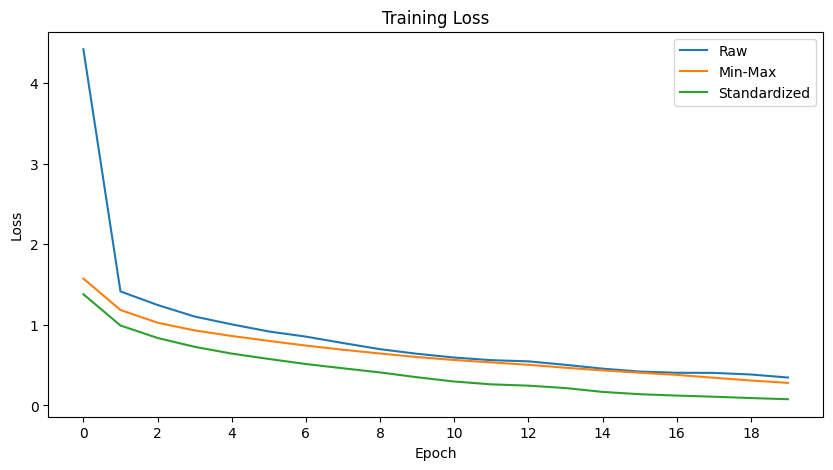

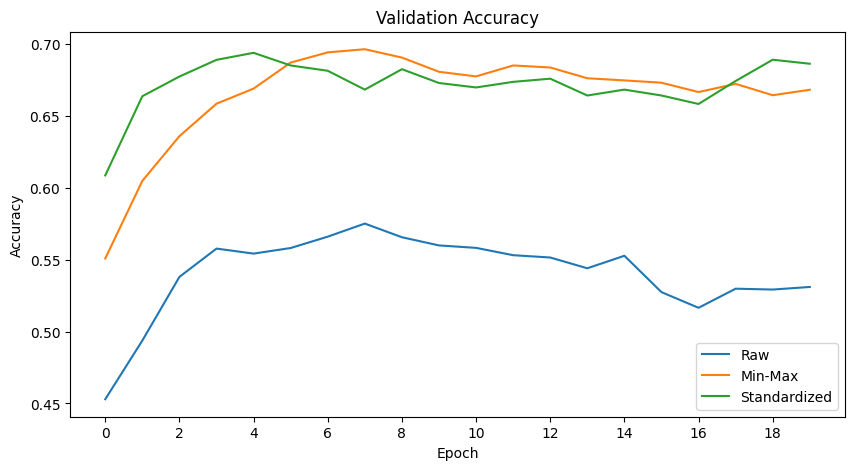

In [ ]:
from tensorflow import keras
def BaselineCNN():
  model = models.Sequential([
      layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
      layers.MaxPooling2D((2, 2)),
      layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
      layers.MaxPooling2D((2, 2)),
      layers.Flatten(),
      layers.Dense(128, activation='relu'),
      layers.Dense(10, activation='softmax')
  ])
  return model

# EXP A
x_train_A = x_train.copy()
x_val_A = x_val.copy()
x_test_A = x_test.copy()

# EXP B
x_train_B = x_train / 255.0
x_val_B = x_val / 255.0
x_test_B = x_test / 255.0

# EXP C
mean = x_train.mean(axis=(0, 1, 2)) 
std = x_train.std(axis=(0, 1, 2))

x_train_C = (x_train - mean) / std
x_val_C = (x_val - mean) / std
x_test_C = (x_test - mean) / std

# Training Config
EPOCHS = 20
BATCH_SIZE = 128

# Dictionary to store different preprocessing versions of the dataset
experiments = {
    'Raw': (x_train_A, x_val_A,  x_test_A),
    'Min-Max': (x_train_B, x_val_B,  x_test_B),  
    'Standardized': (x_train_C, x_val_C,  x_test_C),
}

histories = {}
# Loop over each preprocessing method
for name, (x_tr, x_v, x_te) in experiments.items():
    model = BaselineCNN()
    model.compile(
        optimizer=keras.optimizers.Adam(0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    history = model.fit(
        x_tr, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(x_v, y_val),
        verbose=1
    )
    
    # Save training history (used later for plotting curves)
    histories[name] = history
    loss, acc = model.evaluate(x_te, y_test, verbose=0)
    print(f"{name} → Test Acc: {acc*100:.2f}%  |  Loss: {loss:.4f}")


# Plot 1: Training Loss
plt.figure(figsize=(10, 5))
for name, h in histories.items():
    plt.plot(h.history['loss'], label=name)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.xticks(range(0, EPOCHS, 2))
plt.show()

# Plot 2: Validation Accuracy
plt.figure(figsize=(10, 5))
for name, h in histories.items():
    plt.plot(h.history['val_accuracy'], label=name)
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.xticks(range(0, EPOCHS, 2))
plt.show()

## 🔴 1B. Data Augmentation Comparison

### ⚫ Description: Using the standardized data from Exp C, train the BaselineCNN with and without data augmentation

Epoch 1/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - accuracy: 0.5082 - loss: 1.3882 - val_accuracy: 0.6176 - val_loss: 1.1209
Epoch 2/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.6543 - loss: 0.9883 - val_accuracy: 0.6656 - val_loss: 0.9767
Epoch 3/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 47ms/step - accuracy: 0.7112 - loss: 0.8340 - val_accuracy: 0.6777 - val_loss: 0.9333
Epoch 4/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.7497 - loss: 0.7249 - val_accuracy: 0.6863 - val_loss: 0.9380
Epoch 5/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.7811 - loss: 0.6408 - val_accuracy: 0.6859 - val_loss: 0.9598
Epoch 6/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.8059 - loss: 0.5691 - val_accuracy: 0.6884 - val_loss: 0.9759
Epoch 7/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 45ms/step - accuracy: 0.8285 - loss: 0.4992 - val_accuracy: 0.6892 - val_loss: 1.0038
Epoch 8/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.8528 - loss: 0.4318 - 

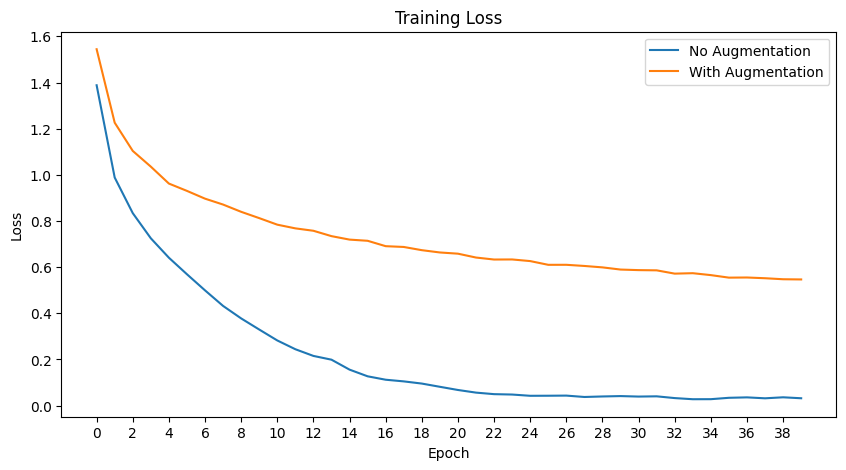

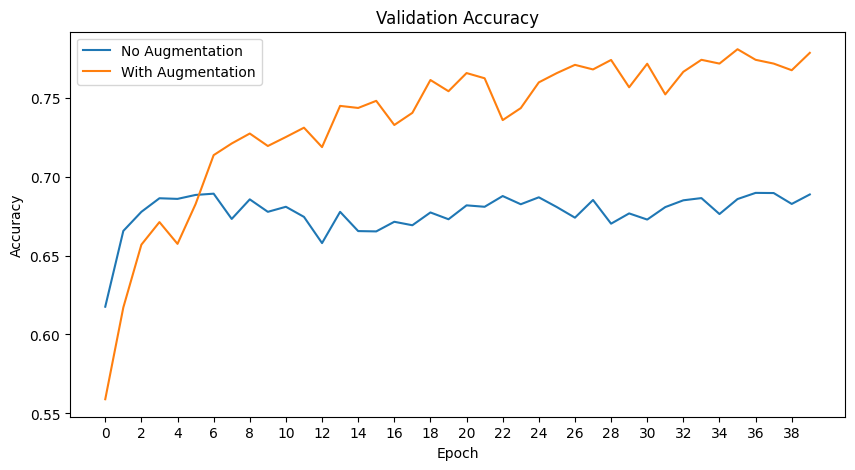

In [3]:
# Training Config
EPOCHS = 40
BATCH_SIZE = 128

# Exp 1 : No Augmentation
model_withoutAug = BaselineCNN()
model_withoutAug.compile(optimizer=keras.optimizers.Adam(0.001),
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

history_withoutAug = model_withoutAug.fit(x_train_C, y_train,
                                         epochs=EPOCHS, batch_size=BATCH_SIZE,
                                         validation_data=(x_val_C, y_val), verbose=1)

loss_withoutAug, acc_withoutAug = model_withoutAug.evaluate(x_test_C, y_test, verbose=0)
print(f"No Augmentation → Test Acc: {acc_withoutAug*100:.2f}%  |  Loss: {loss_withoutAug:.4f}")

# Exp 2: With Augmentation 
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(x_train_C)

model_withAug = BaselineCNN()
model_withAug.compile(optimizer=keras.optimizers.Adam(0.001),
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

history_withAug = model_withAug.fit(datagen.flow(x_train_C, y_train, batch_size=BATCH_SIZE),
                                    epochs=EPOCHS,
                                    validation_data=(x_val_C, y_val), verbose=1)

loss_withAug, acc_withAug = model_withAug.evaluate(x_test_C, y_test, verbose=0)
print(f"With Augmentation → Test Acc: {acc_withAug*100:.2f}%  |  Loss: {loss_withAug:.4f}")

# Plot 1: Training Loss
plt.figure(figsize=(10, 5))
plt.plot(history_withoutAug.history['loss'], label='No Augmentation')
plt.plot(history_withAug.history['loss'], label='With Augmentation')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(0, EPOCHS, 2))
plt.legend()
plt.show()

# Plot 2: Validation Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history_withoutAug.history['val_accuracy'], label='No Augmentation')
plt.plot(history_withAug.history['val_accuracy'], label='With Augmentation')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(range(0, EPOCHS, 2))
plt.legend()
plt.show()

# 🟢 Task 2: CNN Architecture Experiments

## ⚫ Use standardized data for ALL experiments in this task.

## 🔴 2A. Filter Count Comparison

### ⚫ Description: Testing Small, Medium, and Large filter configurations.

In [4]:
pass

## 🔴 2B. Network Depth Comparison

### ⚫ Description: Comparing Shallow (4 layers), Medium (6 layers), and Deep (8 layers).

In [5]:
pass

# 🟢 Task 3: Regularization Experiments

## ⚫ Use the Medium model from Task 2A as the baseline for all experiments.

## 🔴 3A. Dropout Rate Comparison

### ⚫ Description: Comparing rates of 0.0, 0.25, and 0.5.

In [6]:
pass

## 🔴 3B. Early Stopping Comparison

### ⚫ Description: Comparing no ES vs. patience=5 vs. patience=10.

In [7]:
pass

# 🟢 Task 4: Optimizer Comparison

## ⚫ Use the Medium model from Task 2A. Use standardized data.

## 🔴 4A. Same Learning Rate — 5 Optimizers.

### ⚫ Description: SGD, Momentum, AdaGrad, RMSProp, and Adam.

### ⚫ Train with all 5 optimizers at learning_rate = 0.001, 30 epochs, batch_size=128 

In [8]:
pass

## 🔴 4B. Learning Rate Sensitivity — Adam

### ⚫ Description: Testing LR values: 0.0001, 0.001, 0.01. (30 epochs, batch_size=128)

In [9]:
pass

# 🟢 Task 5: Performance Evaluation

## 🔴 5A. Best Model Selection

In [10]:
pass

## 🔴 5B. Error Analysis

In [16]:
pass

# 🟢 Task 6: Transfer Learning

## 🔴 6A. Feature Extraction vs Fine-Tuning vs From Scratch

### ⚫ Step 1 — Resize CIFAR-10 for VGG16: 

In [11]:
pass

### ⚫ Model 1: From Scratch 

- Build the Medium CNN from Task 2A with input_shape=(48, 48, 3). Train 20 epochs, Adam(lr=0.001),  batch_size=128. 

In [12]:
pass

### ⚫ Model 2 — Feature Extraction (Frozen VGG16) 

- Load a pre-trained VGG16 model (trained on ImageNet) without the top classification layers. 

- Freeze ALL VGG16 layers so their weights do not update during training.

- Add your own classification head on top. 

In [13]:
pass

### ⚫ Model 3 — Fine-Tuning (Partial Unfreeze) 

- Load a pre-trained VGG16 model (same as Model 2). 

- Freeze all layers EXCEPT the last 4 layers — these will be re-trained on CIFAR-10.

- Add the same classification head (Flatten → Dense(256) → Dropout → Dense(10)). 

- Use a LOWER learning rate (1e-5) to avoid destroying the pre-trained weights. 

In [14]:
pass

### ⚫ Model 4 — Fine-Tuning (Higher Learning Rate)

- Same architecture and frozen layers as Model 3 (unfreeze last 4 VGG16 layers), but use a higher learning  rate (lr=0.001) instead of 1e-5.

In [15]:
pass